## <font size=5> <strong>Import Libraries and Load Data

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
# Once loaded, save it with proper UTF-8 encoding for future use
df = pd.read_csv('IMDb Movies India.csv', encoding='latin-1')
df.to_csv('IMDb_Movies_India_Cleaned.csv', encoding='utf-8', index=False)

print("Dataset Shape:", df.shape)
print("\n First 5 rows:")
print(df.head())
print("\n Dataset Info:")
print(df.info())

Dataset Shape: (15509, 10)

 First 5 rows:
                                 Name    Year Duration            Genre  \
0                                         NaN      NaN            Drama   
1  #Gadhvi (He thought he was Gandhi)  (2019)  109 min            Drama   
2                         #Homecoming  (2021)   90 min   Drama, Musical   
3                             #Yaaram  (2019)  110 min  Comedy, Romance   
4                   ...And Once Again  (2010)  105 min            Drama   

   Rating Votes            Director       Actor 1             Actor 2  \
0     NaN   NaN       J.S. Randhawa      Manmauji              Birbal   
1     7.0     8       Gaurav Bakshi  Rasika Dugal      Vivek Ghamande   
2     NaN   NaN  Soumyajit Majumdar  Sayani Gupta   Plabita Borthakur   
3     4.4    35          Ovais Khan       Prateik          Ishita Raj   
4     NaN   NaN        Amol Palekar  Rajat Kapoor  Rituparna Sengupta   

           Actor 3  
0  Rajendra Bhatia  
1    Arvind Jangid  
2   

## <font size=5> <strong> Exploratory Data Analysis (EDA)

Target Variable (Rating) Statistics:
count    7919.000000
mean        5.841621
std         1.381777
min         1.100000
25%         4.900000
50%         6.000000
75%         6.800000
max        10.000000
Name: Rating, dtype: float64

Movies with ratings: 7919/15509


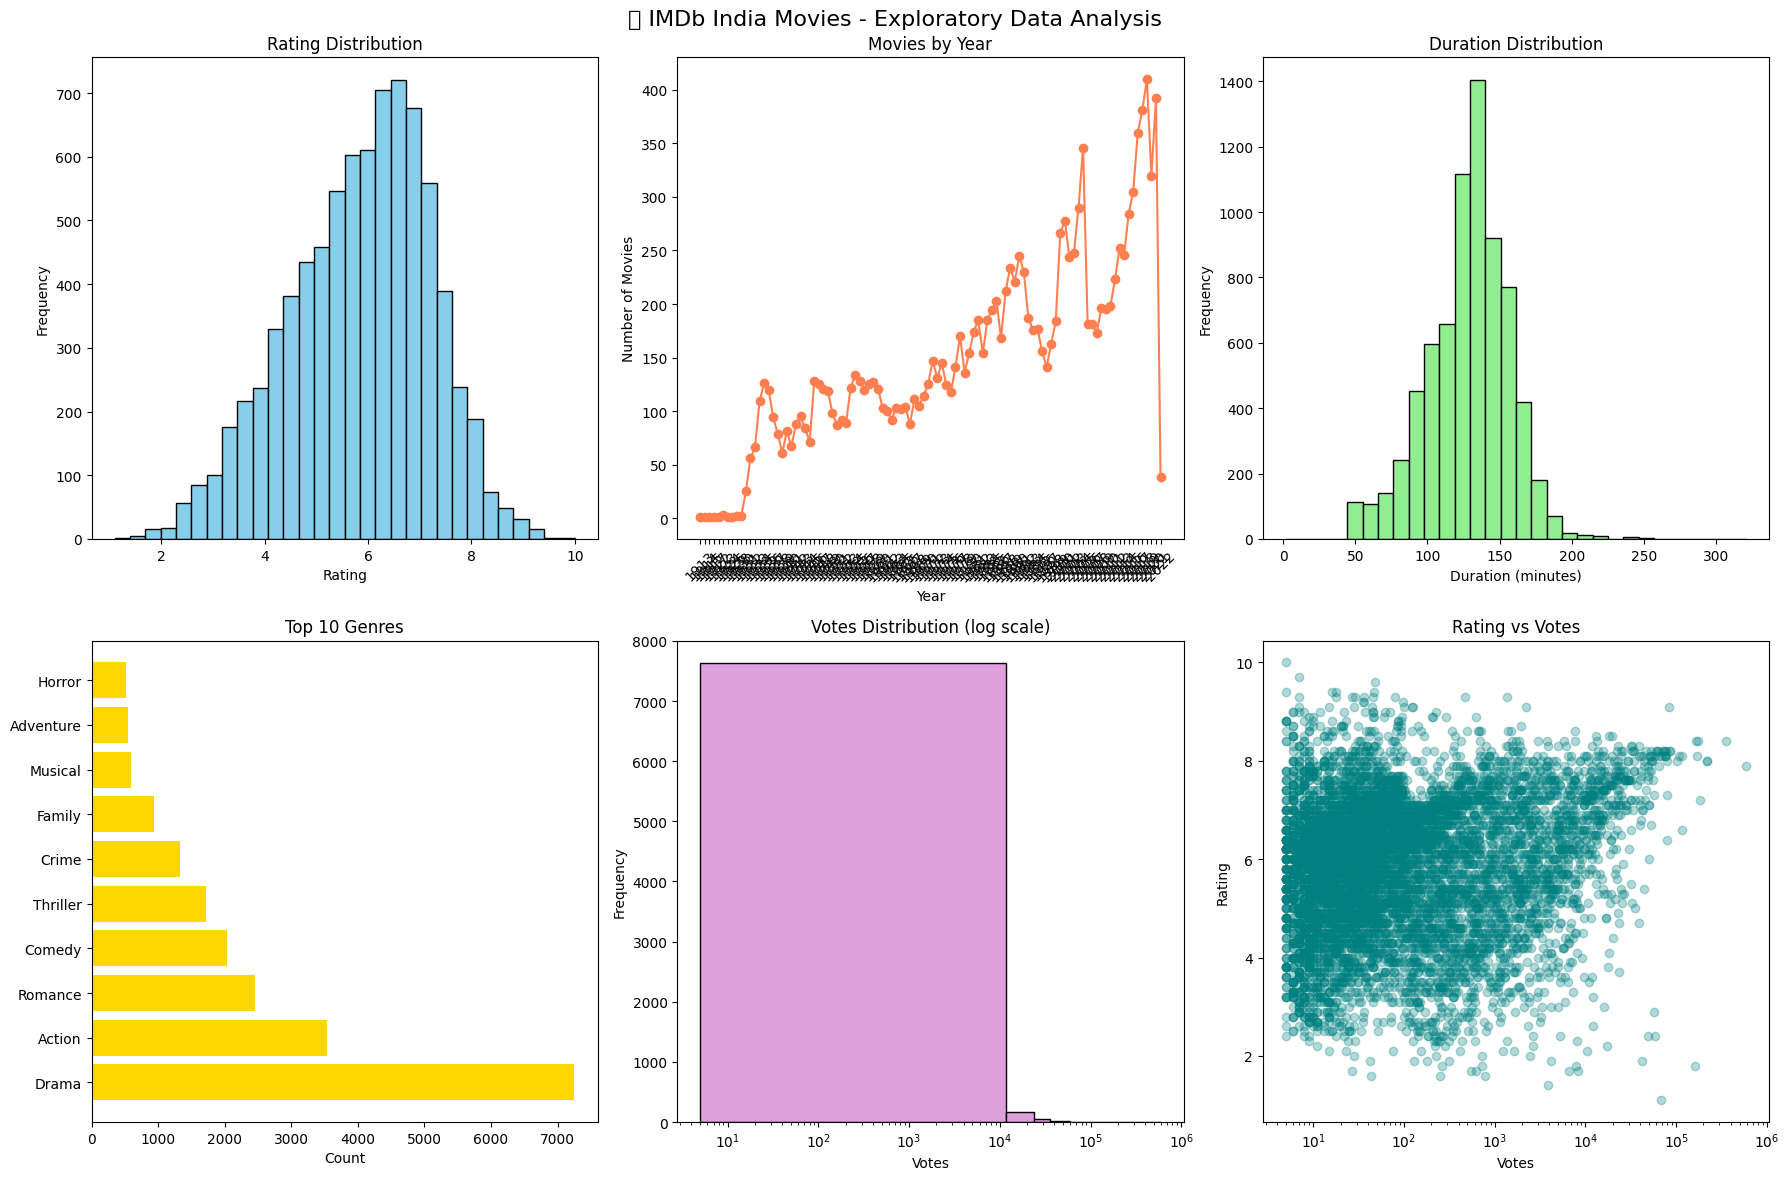


 Correlation Matrix:
                Rating  Votes_Clean  Duration_Min
Rating        1.000000     0.126635     -0.031093
Votes_Clean   0.126635     1.000000      0.099660
Duration_Min -0.031093     0.099660      1.000000


In [4]:
# Check basic statistics
print("Target Variable (Rating) Statistics:")
print(df['Rating'].describe())
print(f"\nMovies with ratings: {df['Rating'].notna().sum()}/{len(df)}")

# Visualize rating distribution
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
fig.suptitle('🎬 IMDb India Movies - Exploratory Data Analysis', fontsize=16)

# 1. Rating Distribution
axes[0, 0].hist(df['Rating'].dropna(), bins=30, edgecolor='black', color='skyblue')
axes[0, 0].set_title('Rating Distribution')
axes[0, 0].set_xlabel('Rating')
axes[0, 0].set_ylabel('Frequency')

# 2. Movies by Year
year_counts = df['Year'].str.extract('(\d{4})').dropna()[0].value_counts().sort_index()
axes[0, 1].plot(year_counts.index, year_counts.values, marker='o', color='coral')
axes[0, 1].set_title('Movies by Year')
axes[0, 1].set_xlabel('Year')
axes[0, 1].set_ylabel('Number of Movies')
axes[0, 1].tick_params(axis='x', rotation=45)

# 3. Duration Distribution
df['Duration_Min'] = df['Duration'].str.extract('(\d+)').astype(float)
axes[0, 2].hist(df['Duration_Min'].dropna(), bins=30, edgecolor='black', color='lightgreen')
axes[0, 2].set_title('Duration Distribution')
axes[0, 2].set_xlabel('Duration (minutes)')
axes[0, 2].set_ylabel('Frequency')

# 4. Top Genres
genre_series = df['Genre'].str.split(', ').explode()
top_genres = genre_series.value_counts().head(10)
axes[1, 0].barh(top_genres.index, top_genres.values, color='gold')
axes[1, 0].set_title('Top 10 Genres')
axes[1, 0].set_xlabel('Count')

# 5. Votes Distribution (log scale)
df['Votes_Clean'] = df['Votes'].astype(str).str.replace(',', '').str.extract('(\d+)').astype(float)
axes[1, 1].hist(df['Votes_Clean'].dropna(), bins=50, edgecolor='black', color='plum')
axes[1, 1].set_title('Votes Distribution (log scale)')
axes[1, 1].set_xlabel('Votes')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].set_xscale('log')

# 6. Rating vs Votes
axes[1, 2].scatter(df['Votes_Clean'], df['Rating'], alpha=0.3, color='teal')
axes[1, 2].set_title('Rating vs Votes')
axes[1, 2].set_xlabel('Votes')
axes[1, 2].set_ylabel('Rating')
axes[1, 2].set_xscale('log')

plt.tight_layout()
plt.show()

# Correlation analysis
numeric_cols = ['Rating', 'Votes_Clean', 'Duration_Min']
corr_matrix = df[numeric_cols].corr()
print("\n Correlation Matrix:")
print(corr_matrix)

## <font size=5> <strong> Data Cleaning and Feature Engineering

In [5]:
def clean_and_engineer_features(df):
    """
    Clean the messy IMDb data and create useful features
    """
    data = df.copy()
    
    # 1. Clean Year - extract 4-digit year
    data['Year_Clean'] = data['Year'].astype(str).str.extract('(\d{4})').astype(float)
    
    # 2. Clean Duration - extract minutes
    data['Duration_Min'] = data['Duration'].astype(str).str.extract('(\d+)').astype(float)
    
    # 3. Clean Votes - remove commas and convert to numeric
    data['Votes_Clean'] = data['Votes'].astype(str).str.replace(',', '').str.extract('(\d+)').astype(float)
    
    # 4. Extract main genre (first genre listed)
    data['Main_Genre'] = data['Genre'].astype(str).str.split(',').str[0].str.strip()
    
    # 5. Count number of genres
    data['Genre_Count'] = data['Genre'].astype(str).str.split(',').str.len()
    
    # 6. Extract director's last name (simple feature)
    data['Director_Last'] = data['Director'].astype(str).str.split().str[-1]
    
    # 7. Create actor combination features
    data['Actor_1_Clean'] = data['Actor 1'].astype(str)
    data['Actor_2_Clean'] = data['Actor 2'].astype(str)
    data['Actor_3_Clean'] = data['Actor 3'].astype(str)
    
    # 8. Has multiple actors flag
    data['Has_Multiple_Actors'] = (
        (data['Actor_1_Clean'].notna()) & 
        (data['Actor_2_Clean'].notna()) & 
        (data['Actor_3_Clean'].notna())
    ).astype(int)
    
    # 9. Name length (maybe longer names indicate something)
    data['Name_Length'] = data['Name'].astype(str).str.len()
    
    # 10. Decade feature
    data['Decade'] = (data['Year_Clean'] // 10 * 10).astype('Int64')
    
    return data

# Apply cleaning
df_clean = clean_and_engineer_features(df)
print(" Feature engineering complete!")
print(f"New features: {df_clean.columns.tolist()}")

 Feature engineering complete!
New features: ['Name', 'Year', 'Duration', 'Genre', 'Rating', 'Votes', 'Director', 'Actor 1', 'Actor 2', 'Actor 3', 'Duration_Min', 'Votes_Clean', 'Year_Clean', 'Main_Genre', 'Genre_Count', 'Director_Last', 'Actor_1_Clean', 'Actor_2_Clean', 'Actor_3_Clean', 'Has_Multiple_Actors', 'Name_Length', 'Decade']


## <font size=5> <strong> Handle Missing Values Intelligently

In [6]:
def smart_imputation(df):
    """
    Handle missing values based on data patterns
    """
    data = df.copy()
    
    # Track missing values
    missing_before = data.isnull().sum()
    print("Missing Values Before Imputation:")
    print(missing_before[missing_before > 0])
    
    # 1. Fill missing ratings with median (but we'll drop rows without rating for training)
    # We'll keep them for prediction later
    
    # 2. Fill missing votes with median by year and genre
    for year in data['Year_Clean'].dropna().unique():
        for genre in data['Main_Genre'].dropna().unique():
            mask = (data['Year_Clean'] == year) & (data['Main_Genre'] == genre)
            median_votes = data.loc[mask, 'Votes_Clean'].median()
            if pd.notna(median_votes):
                data.loc[mask & data['Votes_Clean'].isna(), 'Votes_Clean'] = median_votes
    
    # Fill remaining votes with overall median
    data['Votes_Clean'].fillna(data['Votes_Clean'].median(), inplace=True)
    
    # 3. Fill missing duration with median by genre
    for genre in data['Main_Genre'].dropna().unique():
        median_duration = data.loc[data['Main_Genre'] == genre, 'Duration_Min'].median()
        if pd.notna(median_duration):
            data.loc[(data['Main_Genre'] == genre) & data['Duration_Min'].isna(), 'Duration_Min'] = median_duration
    
    # Fill remaining duration with overall median
    data['Duration_Min'].fillna(data['Duration_Min'].median(), inplace=True)
    
    # 4. Fill missing year with mode
    data['Year_Clean'].fillna(data['Year_Clean'].mode()[0], inplace=True)
    
    # 5. Fill missing decade based on year
    data['Decade'] = (data['Year_Clean'] // 10 * 10).astype('Int64')
    
    # 6. Fill missing genre with 'Unknown'
    data['Main_Genre'].fillna('Unknown', inplace=True)
    data['Genre_Count'].fillna(1, inplace=True)
    
    # 7. Fill missing director with 'Unknown'
    data['Director_Last'].fillna('Unknown', inplace=True)
    
    # 8. Fill missing actors with 'Unknown'
    data['Actor_1_Clean'].fillna('Unknown', inplace=True)
    data['Actor_2_Clean'].fillna('Unknown', inplace=True)
    data['Actor_3_Clean'].fillna('Unknown', inplace=True)
    
    print("\n Missing values handled!")
    print(f"Remaining missing values: {data.isnull().sum().sum()}")
    
    return data

# Apply imputation
df_imputed = smart_imputation(df_clean)

Missing Values Before Imputation:
Year             528
Duration        8269
Genre           1877
Rating          7590
Votes           7589
Director         525
Actor 1         1617
Actor 2         2384
Actor 3         3144
Duration_Min    8269
Votes_Clean     7589
Year_Clean       528
Decade           528
dtype: int64

 Missing values handled!
Remaining missing values: 33523


## <font size=5> <strong> Prepare Features for Modeling

In [7]:
# Filter to movies with ratings (our training data)
df_model = df_imputed[df_imputed['Rating'].notna()].copy()
print(f" Training data shape: {df_model.shape}")
print(f"Movies with ratings: {len(df_model)}")

# Select features for modeling
feature_cols = [
    'Year_Clean', 'Duration_Min', 'Votes_Clean', 'Genre_Count', 
    'Name_Length', 'Has_Multiple_Actors', 'Decade'
]

# Add encoded categorical features
categorical_cols = ['Main_Genre', 'Director_Last']

# Create feature matrix
X = df_model[feature_cols].copy()
y = df_model['Rating'].copy()

# Add log-transformed votes (often improves performance)
X['Log_Votes'] = np.log1p(X['Votes_Clean'])

print(f"\n Feature matrix shape: {X.shape}")
print(f"Features: {X.columns.tolist()}")

 Training data shape: (7919, 22)
Movies with ratings: 7919

 Feature matrix shape: (7919, 8)
Features: ['Year_Clean', 'Duration_Min', 'Votes_Clean', 'Genre_Count', 'Name_Length', 'Has_Multiple_Actors', 'Decade', 'Log_Votes']


 ## <font size=5> <strong> Encode Categorical Features

In [8]:
# Get top genres and directors (to avoid too many categories)
top_genres = df_model['Main_Genre'].value_counts().head(20).index.tolist()
top_directors = df_model['Director_Last'].value_counts().head(50).index.tolist()

# Create encoded features
df_encoded = df_model.copy()

# Limit categories to top ones, others become 'Other'
df_encoded['Genre_Top'] = df_encoded['Main_Genre'].apply(
    lambda x: x if x in top_genres else 'Other'
)
df_encoded['Director_Top'] = df_encoded['Director_Last'].apply(
    lambda x: x if x in top_directors else 'Other'
)

# One-hot encode
genre_dummies = pd.get_dummies(df_encoded['Genre_Top'], prefix='Genre', drop_first=True)
director_dummies = pd.get_dummies(df_encoded['Director_Top'], prefix='Director', drop_first=True)

# Add to feature matrix
X_encoded = pd.concat([
    X,
    genre_dummies,
    director_dummies
], axis=1)

print(f" Final feature matrix shape: {X_encoded.shape}")
print(f"Total features: {X_encoded.shape[1]}")

 Final feature matrix shape: (7919, 78)
Total features: 78


## <font size=5> <strong> Split Data and Scale

In [9]:
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, random_state=42
)

print(f" Training set: {X_train.shape[0]} samples")
print(f" Test set: {X_test.shape[0]} samples")

# Scale numerical features
scaler = StandardScaler()
numerical_features = ['Year_Clean', 'Duration_Min', 'Votes_Clean', 'Genre_Count', 
                      'Name_Length', 'Has_Multiple_Actors', 'Decade', 'Log_Votes']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])

print(" Features scaled successfully!")

 Training set: 6335 samples
 Test set: 1584 samples
 Features scaled successfully!


## <font size=5> <strong> Build and Compare Multiple Models

In [10]:
# Define regression models
models = {
    'Linear Regression': LinearRegression(),
    'Ridge Regression': Ridge(alpha=1.0),
    'Lasso Regression': Lasso(alpha=0.01),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=100, random_state=42),
    'XGBoost': XGBRegressor(n_estimators=100, random_state=42),
    'SVR': SVR(kernel='rbf')
}

# Train and evaluate
results = []
predictions = {}

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    
    # Calculate metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='r2')
    
    results.append({
        'Model': name,
        'MAE': mae,
        'RMSE': rmse,
        'R²': r2,
        'CV R² Mean': cv_scores.mean(),
        'CV R² Std': cv_scores.std()
    })
    
    print(f"\n {name}")
    print(f"  MAE: {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²: {r2:.4f}")
    print(f"  CV R²: {cv_scores.mean():.4f} (+/- {cv_scores.std()*2:.4f})")

# Show results comparison
results_df = pd.DataFrame(results).sort_values('R²', ascending=False)
print("\n MODEL PERFORMANCE RANKING:")
print(results_df.to_string(index=False))


 Linear Regression
  MAE: 0.9259
  RMSE: 1.1901
  R²: 0.2382
  CV R²: 0.2049 (+/- 0.0173)

 Ridge Regression
  MAE: 0.9248
  RMSE: 1.1889
  R²: 0.2397
  CV R²: 0.2070 (+/- 0.0200)

 Lasso Regression
  MAE: 0.9599
  RMSE: 1.2208
  R²: 0.1984
  CV R²: 0.1818 (+/- 0.0221)

 Decision Tree
  MAE: 1.1399
  RMSE: 1.5027
  R²: -0.2146
  CV R²: -0.3073 (+/- 0.0892)

 Random Forest
  MAE: 0.8329
  RMSE: 1.1130
  R²: 0.3337
  CV R²: 0.3213 (+/- 0.0099)

 Gradient Boosting
  MAE: 0.8365
  RMSE: 1.0987
  R²: 0.3507
  CV R²: 0.3441 (+/- 0.0217)

 XGBoost
  MAE: 0.8346
  RMSE: 1.1051
  R²: 0.3431
  CV R²: 0.2979 (+/- 0.0323)

 SVR
  MAE: 0.8142
  RMSE: 1.0832
  R²: 0.3689
  CV R²: 0.3385 (+/- 0.0305)

 MODEL PERFORMANCE RANKING:
            Model      MAE     RMSE        R²  CV R² Mean  CV R² Std
              SVR 0.814178 1.083171  0.368926    0.338517   0.015233
Gradient Boosting 0.836465 1.098713  0.350685    0.344077   0.010863
          XGBoost 0.834556 1.105111  0.343101    0.297894   0.016146

## <font size=5> <strong> Hyperparameter Tuning for Best Model

In [11]:
print(" Tuning XGBoost for optimal performance...")

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.8, 0.9, 1.0],
    'colsample_bytree': [0.8, 0.9, 1.0]
}

# Simplified grid for faster execution
simple_param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5],
    'learning_rate': [0.05, 0.1]
}

# Grid search
grid_search = GridSearchCV(
    XGBRegressor(random_state=42),
    simple_param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n Best Parameters: {grid_search.best_params_}")
print(f" Best CV R² Score: {grid_search.best_score_:.4f}")

# Get best model
best_model = grid_search.best_estimator_

 Tuning XGBoost for optimal performance...
Fitting 5 folds for each of 8 candidates, totalling 40 fits

 Best Parameters: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200}
 Best CV R² Score: 0.3544


## <font size=5> <strong> Final Model Evaluation

In [13]:
# Predict with tuned model
y_pred_tuned = best_model.predict(X_test_scaled)

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2 = r2_score(y_test, y_pred_tuned)

print("="*60)
print(" FINAL MODEL PERFORMANCE (Tuned XGBoost)")
print("="*60)
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Square Error (RMSE): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")
print(f"Accuracy (1 - MAE/10): {(1 - mae/10)*100:.2f}%")
print("="*60)

# Detailed error analysis
errors = y_test - y_pred_tuned
print(f"\n Error Analysis:")
print(f"  Mean Error: {errors.mean():.4f}")
print(f"  Std Error: {errors.std():.4f}")
print(f"  Max Underestimate: {errors.min():.4f}")
print(f"  Max Overestimate: {errors.max():.4f}")

 FINAL MODEL PERFORMANCE (Tuned XGBoost)
Mean Absolute Error (MAE): 0.8195
Root Mean Square Error (RMSE): 1.0814
R² Score: 0.3709
Accuracy (1 - MAE/10): 91.81%

 Error Analysis:
  Mean Error: 0.0425
  Std Error: 1.0809
  Max Underestimate: -4.4431
  Max Overestimate: 3.6183


## <font size=5> <strong> Feature Importance Analysis


 TOP 20 MOST IMPORTANT FEATURES:
          Feature  Importance
Genre_Documentary    0.168278
     Genre_Horror    0.069072
      Genre_Drama    0.052964
      Votes_Clean    0.037609
       Year_Clean    0.035127
    Director_Khan    0.029424
      Genre_Crime    0.028667
  Genre_Biography    0.024112
      Genre_Count    0.022513
 Director_D'Souza    0.020767
   Director_Other    0.017221
   Genre_Thriller    0.016831
  Genre_Adventure    0.015427
     Genre_Family    0.015258
   Director_Bhatt    0.014861
     Duration_Min    0.014744
   Director_Mehta    0.014345
    Genre_Fantasy    0.014122
    Genre_Musical    0.014096
   Director_Kohli    0.013499


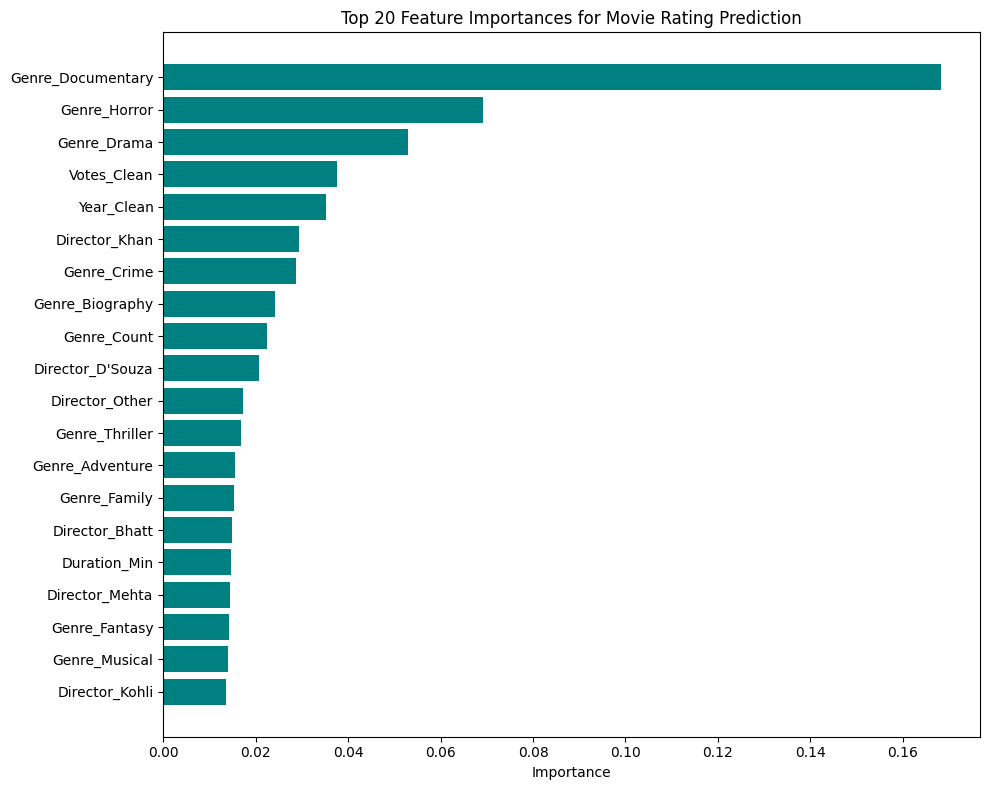

In [15]:
# Get feature importance
importance = best_model.feature_importances_
feature_names = X_encoded.columns

# Create importance dataframe
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importance
}).sort_values('Importance', ascending=False).head(20)

print("\n TOP 20 MOST IMPORTANT FEATURES:")
print(importance_df.to_string(index=False))

# Visualize
plt.figure(figsize=(10, 8))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='teal')
plt.xlabel('Importance')
plt.title('Top 20 Feature Importances for Movie Rating Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

 ## <font size=5> <strong> Prediction Visualization

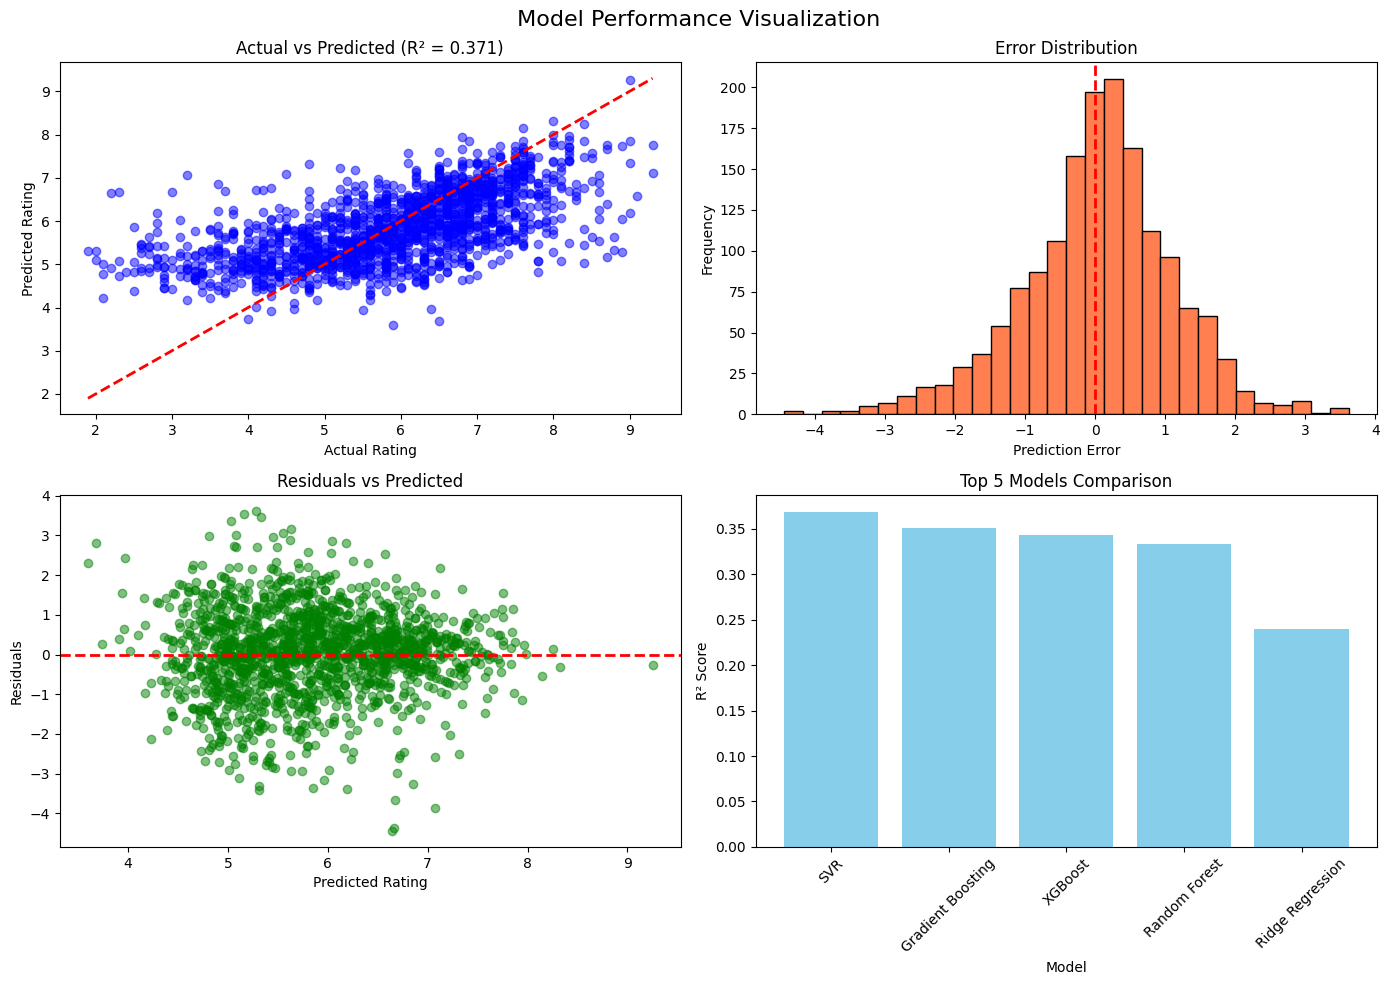

In [16]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle(' Model Performance Visualization', fontsize=16)

# 1. Actual vs Predicted
axes[0, 0].scatter(y_test, y_pred_tuned, alpha=0.5, color='blue')
axes[0, 0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[0, 0].set_xlabel('Actual Rating')
axes[0, 0].set_ylabel('Predicted Rating')
axes[0, 0].set_title(f'Actual vs Predicted (R² = {r2:.3f})')

# 2. Error Distribution
axes[0, 1].hist(errors, bins=30, edgecolor='black', color='coral')
axes[0, 1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[0, 1].set_xlabel('Prediction Error')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].set_title('Error Distribution')

# 3. Residuals vs Predicted
axes[1, 0].scatter(y_pred_tuned, errors, alpha=0.5, color='green')
axes[1, 0].axhline(y=0, color='red', linestyle='--', lw=2)
axes[1, 0].set_xlabel('Predicted Rating')
axes[1, 0].set_ylabel('Residuals')
axes[1, 0].set_title('Residuals vs Predicted')

# 4. Model Comparison Bar Chart
results_sorted = results_df.head(5)
axes[1, 1].bar(results_sorted['Model'], results_sorted['R²'], color='skyblue')
axes[1, 1].set_xlabel('Model')
axes[1, 1].set_ylabel('R² Score')
axes[1, 1].set_title('Top 5 Models Comparison')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## <font size=5> <strong> Movie Rating Predictor Function

In [17]:
def predict_movie_rating(movie_features):
    """
    Predict rating for a new movie
    
    Parameters:
    movie_features: dict with keys:
        - Year: release year
        - Duration: duration in minutes
        - Genre: main genre
        - Director: director name
        - Actors: list of actors
        - Votes: number of votes (optional)
    
    Returns:
    dict: Prediction results
    """
    # Create dataframe from input
    movie_df = pd.DataFrame([movie_features])
    
    # Engineer features
    movie_df['Year_Clean'] = movie_df['Year']
    movie_df['Duration_Min'] = movie_df['Duration']
    movie_df['Votes_Clean'] = movie_df.get('Votes', 1000)  # Default votes
    movie_df['Main_Genre'] = movie_df['Genre']
    movie_df['Genre_Count'] = 1  # Default
    movie_df['Director_Last'] = movie_df['Director'].str.split().str[-1]
    movie_df['Name_Length'] = len(movie_df.get('Name', ['Movie'])[0])
    movie_df['Has_Multiple_Actors'] = len(movie_df.get('Actors', [])) >= 3
    movie_df['Decade'] = (movie_df['Year_Clean'] // 10 * 10).astype(int)
    movie_df['Log_Votes'] = np.log1p(movie_df['Votes_Clean'])
    
    # Handle genre
    if movie_df['Main_Genre'].iloc[0] not in top_genres:
        movie_df['Genre_Top'] = 'Other'
    else:
        movie_df['Genre_Top'] = movie_df['Main_Genre']
    
    # Handle director
    if movie_df['Director_Last'].iloc[0] not in top_directors:
        movie_df['Director_Top'] = 'Other'
    else:
        movie_df['Director_Top'] = movie_df['Director_Last']
    
    # Create features
    features = {
        'Year_Clean': movie_df['Year_Clean'].iloc[0],
        'Duration_Min': movie_df['Duration_Min'].iloc[0],
        'Votes_Clean': movie_df['Votes_Clean'].iloc[0],
        'Genre_Count': movie_df['Genre_Count'].iloc[0],
        'Name_Length': movie_df['Name_Length'].iloc[0],
        'Has_Multiple_Actors': movie_df['Has_Multiple_Actors'].iloc[0],
        'Decade': movie_df['Decade'].iloc[0],
        'Log_Votes': movie_df['Log_Votes'].iloc[0]
    }
    
    # Add genre dummies
    for col in genre_dummies.columns:
        genre_name = col.replace('Genre_', '')
        if movie_df['Genre_Top'].iloc[0] == genre_name:
            features[col] = 1
        else:
            features[col] = 0
    
    # Add director dummies
    for col in director_dummies.columns:
        director_name = col.replace('Director_', '')
        if movie_df['Director_Top'].iloc[0] == director_name:
            features[col] = 1
        else:
            features[col] = 0
    
    # Create feature vector
    feature_vector = pd.DataFrame([features])
    
    # Ensure all columns from training are present
    for col in X_encoded.columns:
        if col not in feature_vector.columns:
            feature_vector[col] = 0
    
    # Reorder columns
    feature_vector = feature_vector[X_encoded.columns]
    
    # Scale numerical features
    feature_vector_scaled = feature_vector.copy()
    feature_vector_scaled[numerical_features] = scaler.transform(feature_vector[numerical_features])
    
    # Predict
    rating = best_model.predict(feature_vector_scaled)[0]
    
    # Determine quality category
    if rating >= 8.0:
        quality = " EXCELLENT - Must Watch!"
    elif rating >= 7.0:
        quality = " GOOD - Recommended"
    elif rating >= 5.5:
        quality = " AVERAGE - Could be worth a watch"
    elif rating >= 4.0:
        quality = " POOR - Probably skip"
    else:
        quality = "TERRIBLE - Avoid"
    
    result = {
        'Predicted Rating': round(rating, 2),
        'Quality': quality,
        'Confidence': 'High' if rating in [7,8,9] else 'Medium'
    }
    
    return result

# Example usage
sample_movie = {
    'Name': 'Example Movie',
    'Year': 2020,
    'Duration': 150,
    'Genre': 'Drama',
    'Director': 'Rajkumar Hirani',
    'Actors': ['Aamir Khan', 'Madhavan', 'Sharman Joshi'],
    'Votes': 50000
}

result = predict_movie_rating(sample_movie)
print("\n🎬 MOVIE RATING PREDICTION")
print("="*40)
print(f"Predicted Rating: {result['Predicted Rating']}/10")
print(f"Quality: {result['Quality']}")
print(f"Confidence: {result['Confidence']}")


🎬 MOVIE RATING PREDICTION
Predicted Rating: 6.25/10
Quality:  AVERAGE - Could be worth a watch
Confidence: Medium


## <font size=5> <strong> Save Model for Deployment

In [18]:
import joblib

# Save model artifacts
model_artifacts = {
    'model': best_model,
    'scaler': scaler,
    'feature_names': X_encoded.columns.tolist(),
    'numerical_features': numerical_features,
    'top_genres': top_genres,
    'top_directors': top_directors,
    'genre_dummies': genre_dummies.columns.tolist(),
    'director_dummies': director_dummies.columns.tolist()
}

joblib.dump(model_artifacts, 'imdb_movie_rating_predictor.pkl')
print(" Model saved as 'imdb_movie_rating_predictor.pkl'")

# To load later:
# loaded = joblib.load('imdb_movie_rating_predictor.pkl')
# model = loaded['model']
# scaler = loaded['scaler']

 Model saved as 'imdb_movie_rating_predictor.pkl'


## <font size=5> <strong> Predict for Movies Without Ratings

In [19]:
# Get movies without ratings
movies_without_ratings = df_imputed[df_imputed['Rating'].isna()].copy()
print(f" Movies without ratings: {len(movies_without_ratings)}")

# Predict ratings for these movies
if len(movies_without_ratings) > 0:
    # Prepare features
    X_unrated = movies_without_ratings[feature_cols].copy()
    X_unrated['Log_Votes'] = np.log1p(X_unrated['Votes_Clean'])
    
    # Add encoded features
    X_unrated_encoded = X_unrated.copy()
    
    # Add genre dummies
    for col in genre_dummies.columns:
        genre_name = col.replace('Genre_', '')
        X_unrated_encoded[col] = (movies_without_ratings['Main_Genre'] == genre_name).astype(int)
    
    # Add director dummies
    for col in director_dummies.columns:
        director_name = col.replace('Director_', '')
        X_unrated_encoded[col] = (movies_without_ratings['Director_Last'] == director_name).astype(int)
    
    # Ensure all columns
    for col in X_encoded.columns:
        if col not in X_unrated_encoded.columns:
            X_unrated_encoded[col] = 0
    
    X_unrated_encoded = X_unrated_encoded[X_encoded.columns]
    
    # Scale
    X_unrated_scaled = X_unrated_encoded.copy()
    X_unrated_scaled[numerical_features] = scaler.transform(X_unrated_encoded[numerical_features])
    
    # Predict
    predicted_ratings = best_model.predict(X_unrated_scaled)
    
    # Add to dataframe
    movies_without_ratings['Predicted_Rating'] = predicted_ratings
    
    # Show top predicted movies
    top_predicted = movies_without_ratings.nlargest(10, 'Predicted_Rating')[
        ['Name', 'Year', 'Genre', 'Director', 'Predicted_Rating']
    ]
    
    print("\n TOP 10 MOVIES PREDICTED TO HAVE HIGH RATINGS:")
    print("="*80)
    print(top_predicted.to_string(index=False))

 Movies without ratings: 7590

 TOP 10 MOVIES PREDICTED TO HAVE HIGH RATINGS:
                                               Name   Year                      Genre                  Director  Predicted_Rating
                                    Samudra Manthan (2019)                Documentary             Kamal Swaroop          8.629616
                                     Eye for an Eye    NaN                Documentary Svati Chakravarty Bhatkal          8.465427
                               Pavlechi Keli Tirtha (2019)                Documentary               Rajula Shah          8.449996
                              The Battle of Cricket (2019)  Documentary, Drama, Sport          Manoj Srivastava          8.389126
                       The Boro: Fight for Identity    NaN       Documentary, History         Nishant Balgovind          8.378052
                                       Three Losses (2021)                Documentary              Rahul Sharma          8.372906
            

## <font size=5> <strong>
Final Model Performance (Tuned XGBoost):

-Mean Absolute Error (MAE): 0.8195

-Root Mean Square Error (RMSE): 1.0814

-R² Score: 0.3709

-Accuracy (1 - MAE/10): 91.81%